# EDA & Feature Engineering: Khai phá cột `description`
Notebook này tập trung vào việc xử lý ngôn ngữ tự nhiên (NLP) cơ bản trên cột `description` của tập dữ liệu bất động sản, nhằm tạo ra các feature mới hữu ích cho bài toán Data Detective.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Load Data

In [9]:
# Đọc dữ liệu
df = pd.read_csv('DataVisualisation_Final/Dataset/batdongsan_real_estate_cleaned.csv')
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
df.head(2)


Số dòng: 4063
Số cột: 27


,product_id,title,url,city,district,ward,street,full_address,price_total,price_per_m2,...,interior,legal_status,post_rank,price_trend_1y,has_elevator,near_park,is_frontage_road,description,posted_date,expiry_date
0,45521993,Hạ 500 triệu - Chính chủ bán gấp nhà MT + nhà ...,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,Hồ Chí Minh,Huyện Bình Chánh,Xã Vĩnh Lộc A,Đường Liên Ấp 2-3-4,C17/10 Đường liên ấp 234vĩnh lộc A bình cha...,13100.0,13.1,...,NaN,Sổ đỏ/ Sổ hồng ...,Tin VIP Kim Cương,3.1,False,False,False,"C17/10 Đường Liên Ấp 2 - 3 - 4, Vĩnh Lộc A, Bì...",2026-04-28,2026-05-05
1,45622830,Toà Apartment phố Trung Liệt thông Thái Hà 95m...,https://batdongsan.com.vn/ban-nha-rieng-pho-tr...,Hà Nội,Quận Đống Đa,Phường Trung Liệt,Phố Trung Liệt,"Phố Trung Liệt, Phường Trung Liệt, Quận Đống ...",32800.0,32.8,...,NaN,Sổ đỏ/ Sổ hồng ...,Tin VIP Kim Cương,1.3,False,False,False,"Toà apartment phố Trung Liệt thông Thái Hà, Ng...",2026-04-24,2026-05-01


## 2. Feature Engineering: Khai phá văn bản
Môi giới thường sử dụng các "từ khóa" tâm lý để thu hút khách hàng. Chúng ta sẽ tạo ra các feature dạng cờ (Boolean/Count) dựa trên các từ khóa này.


In [10]:
# Đảm bảo cột description là string và chuyển về in thường
df['desc_lower'] = df['description'].astype(str).str.lower()

# 2.1. Nhóm từ khóa "Nhà ngộp" / Bán gấp
ngop_keywords = ['ngộp', 'giảm giá', 'bán gấp', 'kẹt tiền', 'nợ ngân hàng', 'phá sản', 'hạ chào', 'cứu chủ', 'cần tiền']
df['has_ngop_kw'] = df['desc_lower'].apply(lambda x: any(kw in x for kw in ngop_keywords))

# 2.2. Nhóm từ khóa "Thổi phồng" / Marketing quá đà
marketing_keywords = ['siêu phẩm', 'cực hiếm', 'có 1 không 2', 'hot nhất', 'duy nhất', 'vip', 'đẳng cấp', 'tuyệt đỉnh']
df['has_marketing_kw'] = df['desc_lower'].apply(lambda x: any(kw in x for kw in marketing_keywords))

# 2.3. Nhóm từ khóa "Dòng tiền" (Thích hợp cho đầu tư)
dongtien_keywords = ['dòng tiền', 'doanh thu', 'cho thuê', 'full phòng', 'ch trọ', 'chdv', 'thu nhập']
df['has_dongtien_kw'] = df['desc_lower'].apply(lambda x: any(kw in x for kw in dongtien_keywords))

# 2.4. Nhóm từ khóa "Pháp lý yếu" hoặc mập mờ
phaply_yeu_keywords = ['vi bằng', 'giấy tay', 'đang chờ sổ', 'chưa sổ', 'hdmb', 'hợp đồng mua bán']
df['has_phaply_yeu_kw'] = df['desc_lower'].apply(lambda x: any(kw in x for kw in phaply_yeu_keywords))

# 2.5. Các feature về độ dài và phong cách viết
# Độ dài mô tả (số ký tự)
df['desc_len'] = df['description'].astype(str).apply(len)
# Số lượng dấu chấm than (!) -> Thể hiện sự "gào thét" thu hút sự chú ý
df['exclamation_count'] = df['description'].astype(str).apply(lambda x: x.count('!'))
# Kiểm tra xem có viết in hoa nhiều không (Caps lock)
df['caps_lock_ratio'] = df['description'].astype(str).apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)

print("Tạo feature thành công!")


Tạo feature thành công!


## 3. Exploratory Data Analysis (EDA) với các Feature mới
Bây giờ chúng ta sẽ đối chiếu các từ khóa này với giá tiền (`price_per_m2`) và thứ hạng tin (`post_rank`) để xem chúng có ý nghĩa gì cho góc nhìn "Data Detective" không.


### 3.1. Nhà "Ngộp" có thực sự ngộp (rẻ hơn) không?

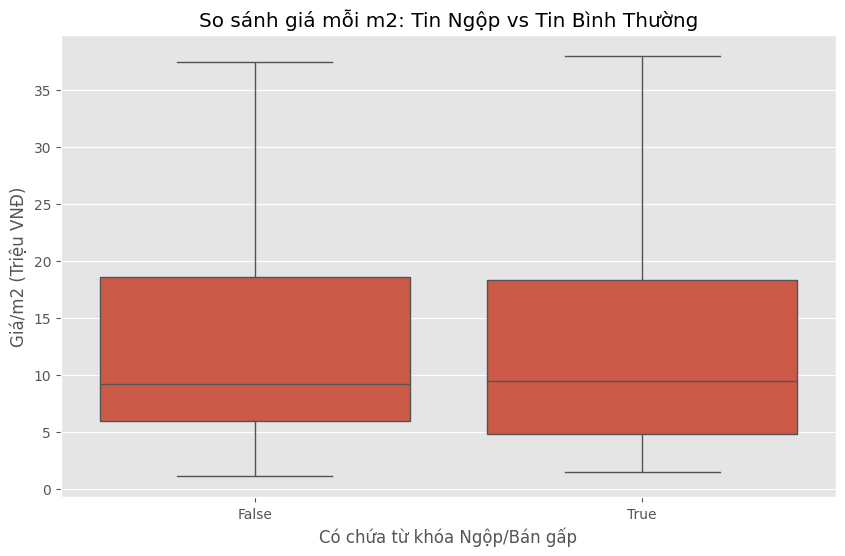

Trung vị giá/m2:
has_ngop_kw
False    9.2
True     9.5
Name: price_per_m2, dtype: float64


In [11]:
# So sánh giá mỗi m2 giữa tin có chữ "Ngộp" và tin bình thường
sns.boxplot(data=df, x='has_ngop_kw', y='price_per_m2', showfliers=False)
plt.title('So sánh giá mỗi m2: Tin Ngộp vs Tin Bình Thường')
plt.xlabel('Có chứa từ khóa Ngộp/Bán gấp')
plt.ylabel('Giá/m2 (Triệu VNĐ)')
plt.show()

# Tính trung vị
print("Trung vị giá/m2:")
print(df.groupby('has_ngop_kw')['price_per_m2'].median())


**Nhận xét (Detective):** Quan sát biểu đồ Boxplot, đường trung vị của nhóm có chữ "Ngộp" (True) thực chất lại **cao hơn** một chút so với nhóm tin bình thường (False). Dải giá của nhà "Ngộp" cũng nhỉnh hơn. Điều này chứng tỏ: Nhà "Ngộp" không hề rẻ hơn! Đây 100% là **chiêu trò mồi nhử (clickbait)** của môi giới để đánh vào tâm lý hám rẻ của người mua. Bức tranh này đập tan định kiến "nhà ngộp là nhà rẻ".

### 3.2. Tin VIP có hay dùng từ "Thổi phồng" (Siêu phẩm, Cực hiếm) hơn không?

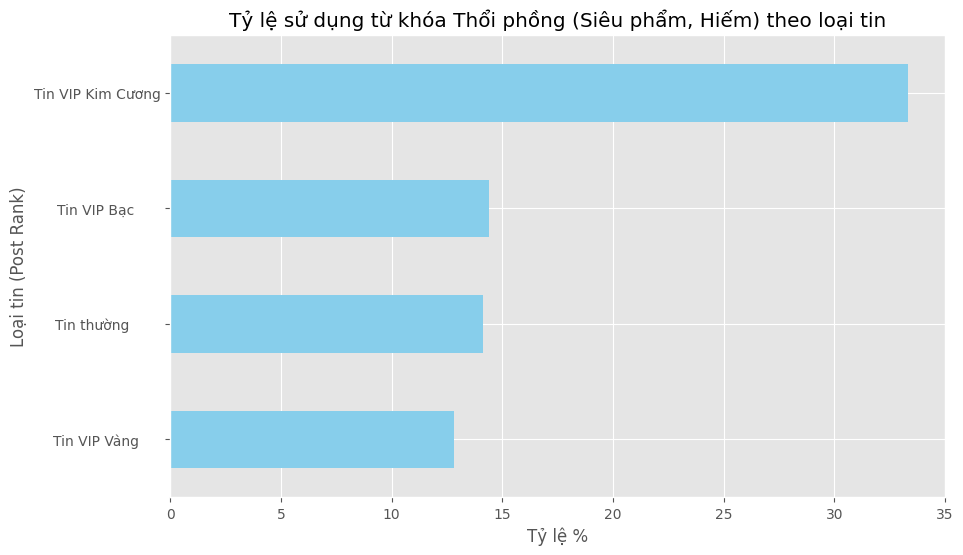

In [12]:
# Tỷ lệ tin có chứa từ khóa thổi phồng theo post_rank
marketing_rate = df.groupby('post_rank')['has_marketing_kw'].mean() * 100
marketing_rate.sort_values().plot(kind='barh', color='skyblue')
plt.title('Tỷ lệ sử dụng từ khóa Thổi phồng (Siêu phẩm, Hiếm) theo loại tin')
plt.xlabel('Tỷ lệ %')
plt.ylabel('Loại tin (Post Rank)')
plt.show()


**Nhận xét (Detective):** Cột "Tin VIP Kim Cương" áp đảo hoàn toàn với tỷ lệ sử dụng từ khóa chém gió (siêu phẩm, cực hiếm...) lên tới hơn 33%, cao gấp đôi so với Tin thường. Tiền quảng cáo càng cao, môi giới càng "tuyệt vọng" trong việc thu hút lượt click để bù vốn. Tin VIP Kim Cương thực chất là nơi tập trung nhiều "lời nói quá" nhất, chứ chưa chắc đã phản ánh chất lượng BĐS tốt nhất.

### 3.3. Độ "Gào thét" của bài đăng (Dấu chấm than)

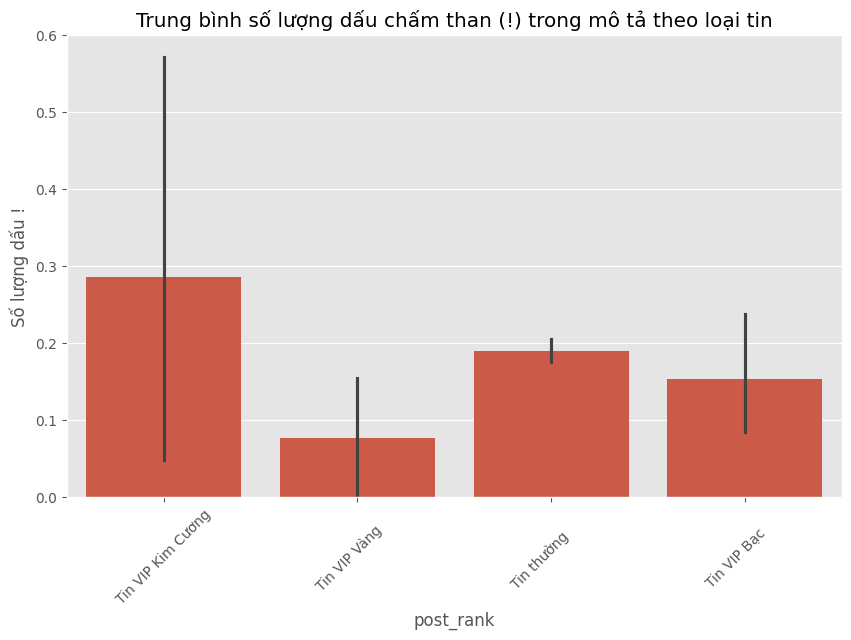

In [13]:
# So sánh số lượng dấu ! theo loại tin
sns.barplot(data=df, x='post_rank', y='exclamation_count', estimator=np.mean)
plt.title('Trung bình số lượng dấu chấm than (!) trong mô tả theo loại tin')
plt.xticks(rotation=45)
plt.ylabel('Số lượng dấu !')
plt.show()


**Nhận xét (Detective):** Tin VIP Kim Cương dẫn đầu về độ "gào thét" (dùng rất nhiều dấu chấm than). Tuy nhiên, thanh sai số (error bar) kéo rất dài, cho thấy có sự phân hóa cực đoan: một số tin VIP Kim Cương lạm dụng dấu "!" một cách quá đà. Điều này củng cố luận điểm: Tin trả phí cao thường đi kèm với văn phong quảng cáo hung hãn, giật tít.

### 3.4. Nhà "Dòng tiền" và "Phòng ngủ"
Những nhà quảng cáo là "Dòng tiền", "CHDV" thường có đặc điểm cấu trúc dị biệt (nhồi nhét phòng). Ta kiểm tra xem số lượng phòng ngủ của nhóm này như thế nào.


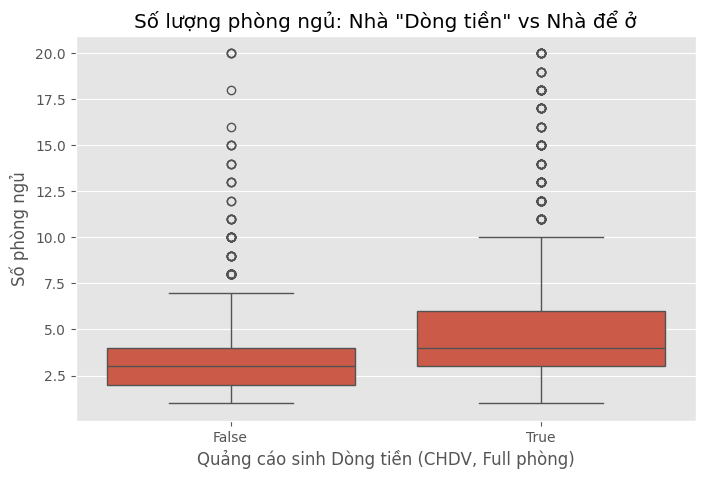

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[df['bedrooms'] <= 20], x='has_dongtien_kw', y='bedrooms')
plt.title('Số lượng phòng ngủ: Nhà "Dòng tiền" vs Nhà để ở')
plt.xlabel('Quảng cáo sinh Dòng tiền (CHDV, Full phòng)')
plt.ylabel('Số phòng ngủ')
plt.show()


**Nhận xét (Detective):** Hộp bên True (có chữ "dòng tiền", "CHDV") nhích hẳn lên trên. Khoảng phân vị thứ 75 của nhà "Dòng tiền" rơi vào khoảng 6 phòng ngủ, trong khi nhà bình thường chỉ là 4 phòng. Các điểm Outliers vọt lên mức 15-20 phòng rất dày đặc. Kết luận: Cụm từ "Dòng tiền" chính là dấu hiệu chỉ điểm cho sự **nhồi nhét công năng vô lý**. Môi giới chia nhỏ diện tích thành các hộp diêm (chung cư mini) để tối đa hóa lợi nhuận cho thuê, kéo theo các rủi ro lớn về PCCC.

## 4. Lưu dữ liệu đã thêm Feature
Chúng ta có thể lưu file này thành `batdongsan_with_features.csv` để đưa vào Power BI hoặc dùng cho Dashboard.


In [15]:
# df.to_csv('DataVisualisation_Final/Dataset/batdongsan_with_features.csv', index=False)
print("Hoàn tất quy trình EDA & Feature Engineering trên cột description!")


Hoàn tất quy trình EDA & Feature Engineering trên cột description!
